# CINF104 — Machine Learning Project 1
## GRD Prediction — Hospital El Pino
### Progress Report: Exploratory Data Analysis + Baseline Model

**Course:** CINF104 Aprendizaje de Máquinas  
**Delivery:** Informe Fase 1 — Avance (EDA + 1 modelo de prueba)  

---
**Dataset columns:**
- `Diag 01 Principal` … `Diag 35 Secundario`: ICD-10 diagnosis codes + descriptions
- `Proced 01 Principal` … `Proced 30 Secundario`: ICD-9-CM procedure codes + descriptions
- `Edad en años`: patient age
- `Sexo (Desc)`: patient sex
- **`GRD`**: target variable — Grupo Relacionado por el Diagnóstico

## 0 · Setup & Imports

In [3]:
# ── Install / upgrade libraries ──────────────────────────────────────────────
!pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

SEED = 42
print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Data Loading

> **Upload** the file `dataset_elpino.csv` when prompted (or mount Google Drive and update `FILE_PATH`).

In [4]:
# ── Option A: upload from local machine ──────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # select dataset_elpino.csv
FILE_PATH = list(uploaded.keys())[0]

# ── Option B: if already in Colab filesystem / Drive ─────────────────────────
# FILE_PATH = '/content/drive/MyDrive/CINF104/dataset_elpino.csv'

df_raw = pd.read_csv(FILE_PATH, sep=';', encoding='utf-8')
print(f'Loaded  {df_raw.shape[0]:,} rows  ×  {df_raw.shape[1]} columns')

Saving dataset_elpino.csv to dataset_elpino (1).csv
Loaded  14,561 rows  ×  68 columns


## 2 · Initial Inspection

In [5]:
# Column names overview
print('=== COLUMNS ===')
for i, col in enumerate(df_raw.columns):
    print(f'  [{i:>2}] {col}')

=== COLUMNS ===
  [ 0] Diag 01 Principal (cod+des)
  [ 1] Diag 02 Secundario (cod+des)
  [ 2] Diag 03 Secundario (cod+des)
  [ 3] Diag 04 Secundario (cod+des)
  [ 4] Diag 05 Secundario (cod+des)
  [ 5] Diag 06 Secundario (cod+des)
  [ 6] Diag 07 Secundario (cod+des)
  [ 7] Diag 08 Secundario (cod+des)
  [ 8] Diag 09 Secundario (cod+des)
  [ 9] Diag 10 Secundario (cod+des)
  [10] Diag 11 Secundario (cod+des)
  [11] Diag 12 Secundario (cod+des)
  [12] Diag 13 Secundario (cod+des)
  [13] Diag 14 Secundario (cod+des)
  [14] Diag 15 Secundario (cod+des)
  [15] Diag 16 Secundario (cod+des)
  [16] Diag 17 Secundario (cod+des)
  [17] Diag 18 Secundario (cod+des)
  [18] Diag 19 Secundario (cod+des)
  [19] Diag 20 Secundario (cod+des)
  [20] Diag 21 Secundario (cod+des)
  [21] Diag 22 Secundario (cod+des)
  [22] Diag 23 Secundario (cod+des)
  [23] Diag 24 Secundario (cod+des)
  [24] Diag 25 Secundario (cod+des)
  [25] Diag 26 Secundario (cod+des)
  [26] Diag 27 Secundario (cod+des)
  [27] Diag 2

In [6]:
df_raw.head(3)

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...


In [7]:
df_raw.dtypes

,0
Diag 01 Principal (cod+des),object
Diag 02 Secundario (cod+des),object
Diag 03 Secundario (cod+des),object
Diag 04 Secundario (cod+des),object
Diag 05 Secundario (cod+des),object
...,...
Proced 29 Secundario (cod+des),object
Proced 30 Secundario (cod+des),object
Edad en años,int64
Sexo (Desc),object


## 3 · Data Quality Analysis
### 3.1 Missing Values

In [8]:
# Treat the placeholder '-' as missing
df = df_raw.replace('-', np.nan)

missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
miss_df = miss_df[miss_df['missing_count'] > 0]
print(f'Columns with missing values: {len(miss_df)}')
miss_df.head(20)

Columns with missing values: 63


,missing_count,missing_%
Diag 35 Secundario (cod+des),14533,99.81
Diag 34 Secundario (cod+des),14521,99.73
Diag 33 Secundario (cod+des),14518,99.70
Diag 32 Secundario (cod+des),14504,99.61
Diag 31 Secundario (cod+des),14494,99.54
Diag 30 Secundario (cod+des),14485,99.48
Diag 29 Secundario (cod+des),14468,99.36
Diag 28 Secundario (cod+des),14451,99.24
Diag 27 Secundario (cod+des),14431,99.11
Diag 26 Secundario (cod+des),14407,98.94


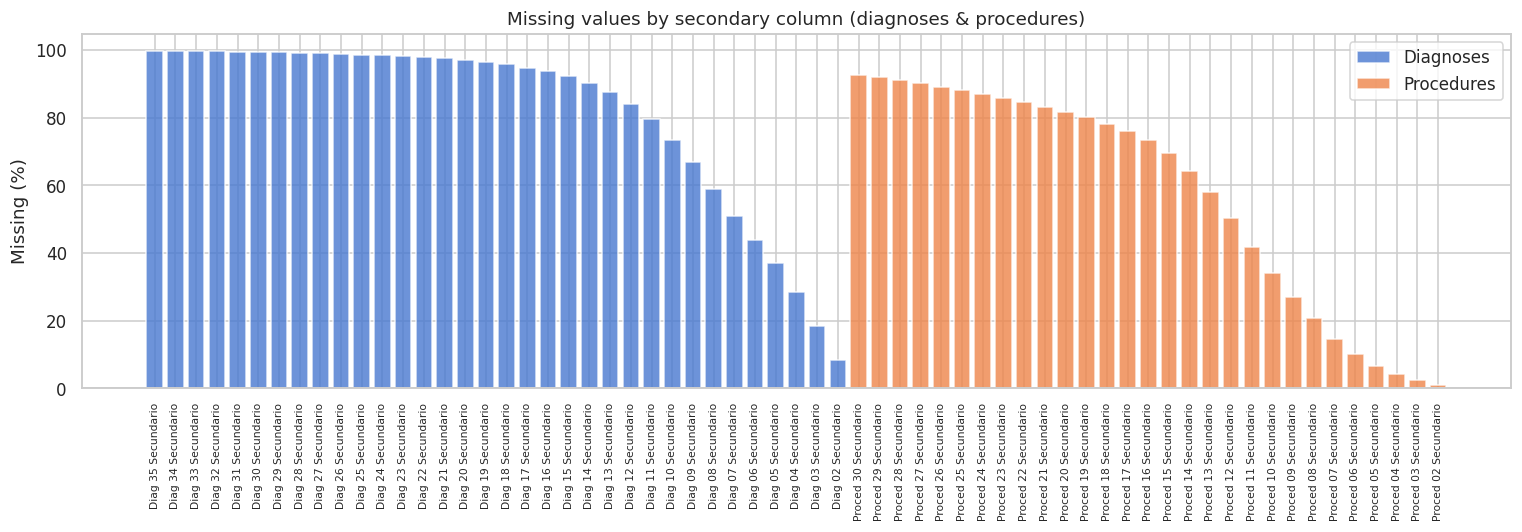

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

# Separate diag, proced, and other columns
diag_miss  = miss_df[miss_df.index.str.startswith('Diag')]
proced_miss = miss_df[miss_df.index.str.startswith('Proced')]

ax.bar(range(len(diag_miss)),  diag_miss['missing_%'],  label='Diagnoses',  alpha=0.8)
ax.bar(range(len(diag_miss), len(diag_miss)+len(proced_miss)),
       proced_miss['missing_%'], label='Procedures', alpha=0.8)

ax.set_xticks(range(len(diag_miss)+len(proced_miss)))
ax.set_xticklabels(
    [c.split('(')[0].strip() for c in list(diag_miss.index)+list(proced_miss.index)],
    rotation=90, fontsize=7)
ax.set_ylabel('Missing (%)')
ax.set_title('Missing values by secondary column (diagnoses & procedures)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_missing_values.png', bbox_inches='tight')
plt.show()

### 3.2 Data Completeness per Row

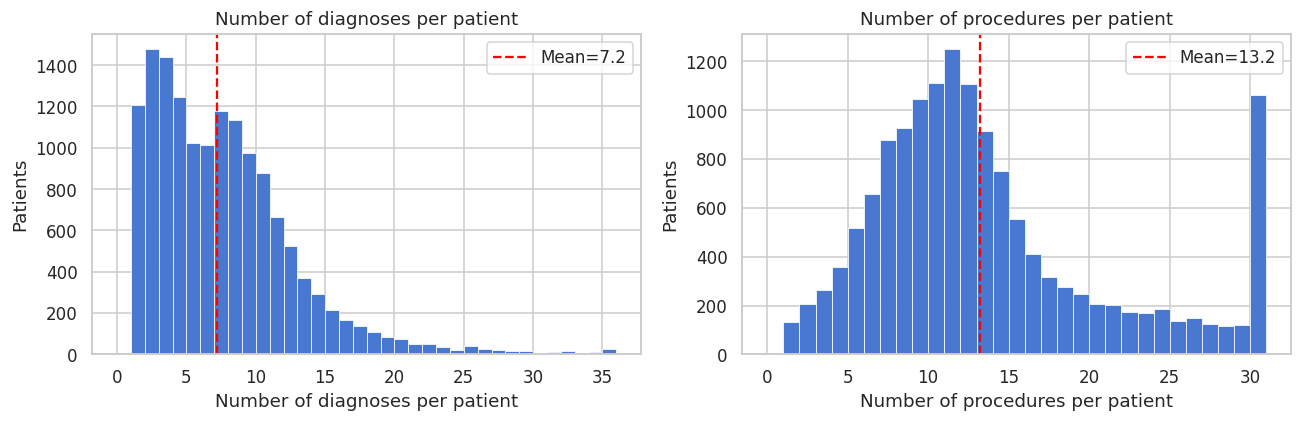

       n_diagnoses  n_procedures
count     14561.00      14561.00
mean          7.17         13.22
std           5.22          7.36
min           1.00          1.00
25%           3.00          8.00
50%           6.00         11.00
75%          10.00         16.00
max          35.00         30.00


In [10]:
diag_cols  = [c for c in df.columns if c.startswith('Diag')]
proced_cols = [c for c in df.columns if c.startswith('Proced')]

df['n_diagnoses']  = df[diag_cols].notna().sum(axis=1)
df['n_procedures'] = df[proced_cols].notna().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes,
                           ['n_diagnoses', 'n_procedures'],
                           ['Number of diagnoses per patient',
                            'Number of procedures per patient']):
    ax.hist(df[col], bins=range(0, df[col].max()+2), edgecolor='white', linewidth=0.5)
    ax.set_xlabel(title)
    ax.set_ylabel('Patients')
    ax.set_title(title)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean={df[col].mean():.1f}')
    ax.legend()
plt.tight_layout()
plt.savefig('fig_completeness_per_row.png', bbox_inches='tight')
plt.show()

print(df[['n_diagnoses','n_procedures']].describe().round(2))

### 3.3 Duplicate Records

In [11]:
dups = df.duplicated().sum()
print(f'Exact duplicate rows: {dups}  ({dups/len(df)*100:.2f}%)')

Exact duplicate rows: 144  (0.99%)


## 4 · Descriptive Statistics
### 4.1 Target Variable — GRD

In [12]:
# Extract GRD code (first numeric part) and description
df['grd_code'] = df['GRD'].str.extract(r'^(\d+)')
df['grd_desc'] = df['GRD'].str.extract(r'^\d+ - (.+)')

grd_counts = df['GRD'].value_counts()
print(f'Total unique GRDs: {grd_counts.nunique()}')
print(f'Most common GRD: {grd_counts.index[0]}  ({grd_counts.iloc[0]:,} patients)')
print(f'Least common GRD: {grd_counts.index[-1]}  ({grd_counts.iloc[-1]:,} patients)')
print(f'\nTop 10 most frequent GRDs:')
grd_counts.head(10)

Total unique GRDs: 104
Most common GRD: 146101 - PH CESÁREA  (813 patients)
Least common GRD: 134153 - MH FALSO TRABAJO DEL PARTO W/MCC  (1 patients)

Top 10 most frequent GRDs:


,count
GRD,
146101 - PH CESÁREA,813
"146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO",639
146131 - PH PARTO VAGINAL,538
"158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR",389
134161 - MH TRASTORNOS DEL ANTEPARTO,325
071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA,317
044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC,287
061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE,252
041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC,248


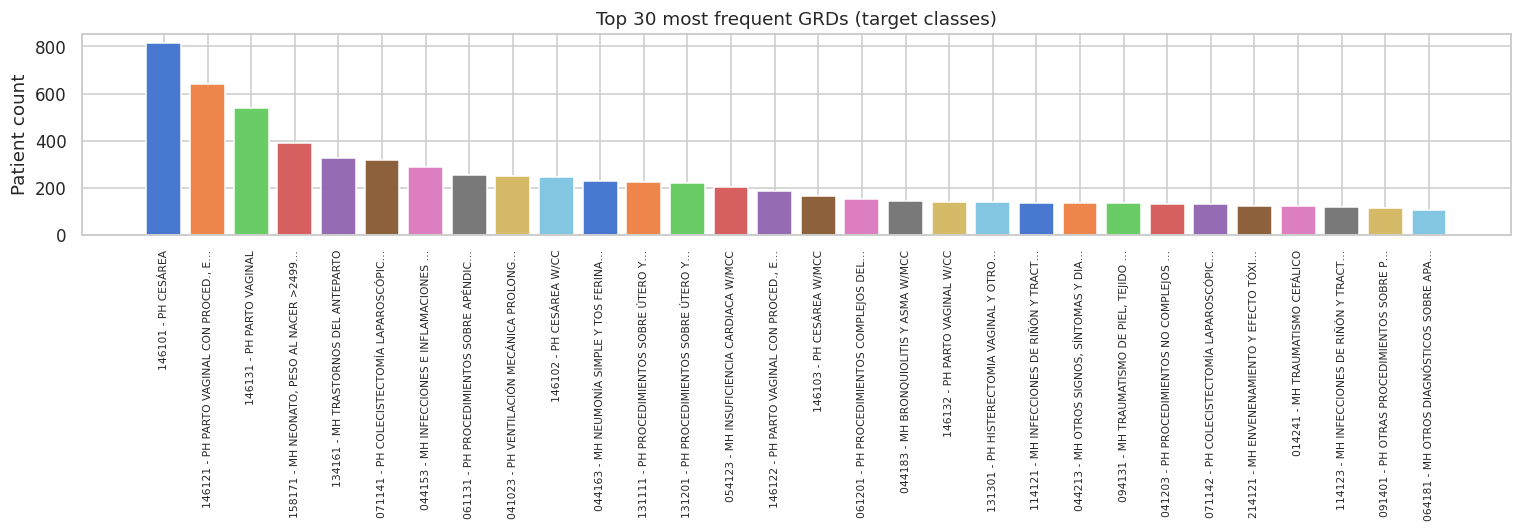


Top 30 GRDs cover 48.8% of all patients


In [13]:
# Class distribution — top 30
top30 = grd_counts.head(30)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(top30)), top30.values, color=sns.color_palette('muted', len(top30)))
ax.set_xticks(range(len(top30)))
ax.set_xticklabels(
    [c[:40]+'…' if len(c)>40 else c for c in top30.index],
    rotation=90, fontsize=7)
ax.set_ylabel('Patient count')
ax.set_title('Top 30 most frequent GRDs (target classes)')
plt.tight_layout()
plt.savefig('fig_grd_top30.png', bbox_inches='tight')
plt.show()

# Class imbalance metrics
pct_covered = top30.sum() / len(df) * 100
print(f'\nTop 30 GRDs cover {pct_covered:.1f}% of all patients')

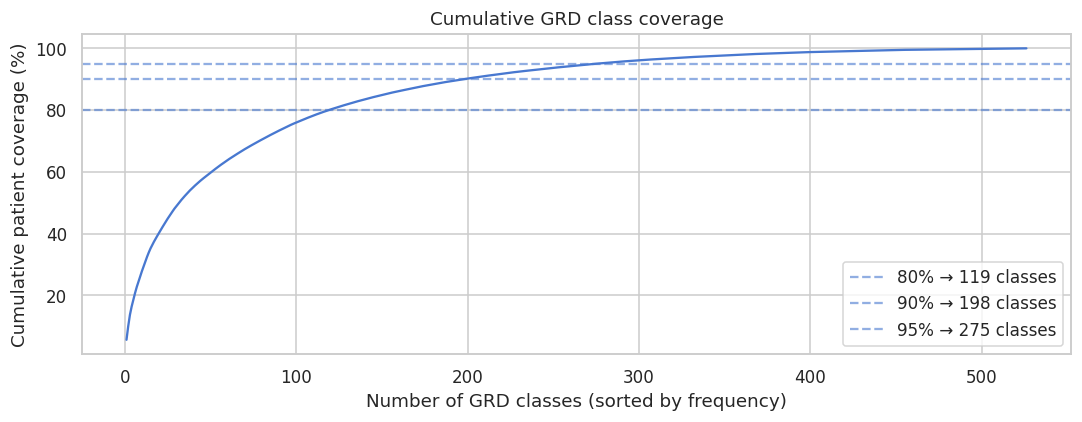

In [14]:
# Cumulative coverage plot
cum_pct = (grd_counts.cumsum() / len(df) * 100)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cum_pct)+1), cum_pct.values)
for threshold in [80, 90, 95]:
    n_classes = (cum_pct < threshold).sum() + 1
    ax.axhline(threshold, linestyle='--', alpha=0.6, label=f'{threshold}% → {n_classes} classes')
ax.set_xlabel('Number of GRD classes (sorted by frequency)')
ax.set_ylabel('Cumulative patient coverage (%)')
ax.set_title('Cumulative GRD class coverage')
ax.legend()
plt.tight_layout()
plt.savefig('fig_cumulative_grd.png', bbox_inches='tight')
plt.show()

### 4.2 Demographic Variables

In [15]:
print('=== AGE ===')
print(df['Edad en años'].describe())
print('\n=== SEX ===')
print(df['Sexo (Desc)'].value_counts())

=== AGE ===
count    14561.000000
mean        39.426550
std         24.681545
min          0.000000
25%         23.000000
50%         36.000000
75%         60.000000
max        121.000000
Name: Edad en años, dtype: float64

=== SEX ===
Sexo (Desc)
Mujer     9617
Hombre    4944
Name: count, dtype: int64


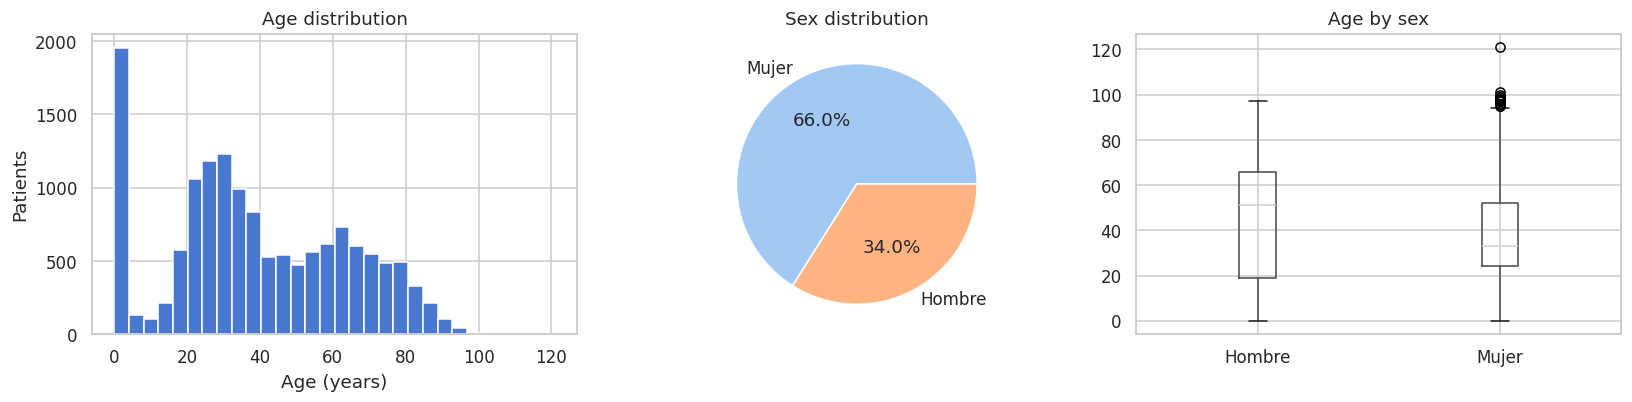

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age histogram
axes[0].hist(df['Edad en años'].dropna(), bins=30, edgecolor='white')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Patients')
axes[0].set_title('Age distribution')

# Sex pie chart
sex_counts = df['Sexo (Desc)'].value_counts()
axes[1].pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel'))
axes[1].set_title('Sex distribution')

# Age box by sex
sex_order = df['Sexo (Desc)'].dropna().unique().tolist()
df_s = df.dropna(subset=['Sexo (Desc)', 'Edad en años'])
df_s.boxplot(column='Edad en años', by='Sexo (Desc)', ax=axes[2])
axes[2].set_title('Age by sex')
axes[2].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.savefig('fig_demographics.png', bbox_inches='tight')
plt.show()

### 4.3 Age outliers

In [17]:
age = df['Edad en años'].dropna()
Q1, Q3 = age.quantile(0.25), age.quantile(0.75)
IQR = Q3 - Q1
low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['Edad en años'] < low) | (df['Edad en años'] > high)]
print(f'IQR range: [{low:.0f}, {high:.0f}]')
print(f'Age outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)')
print(outliers['Edad en años'].describe())

IQR range: [-32, 116]
Age outliers: 1 rows (0.01%)
count      1.0
mean     121.0
std        NaN
min      121.0
25%      121.0
50%      121.0
75%      121.0
max      121.0
Name: Edad en años, dtype: float64


### 4.4 Top Diagnosis & Procedure Codes

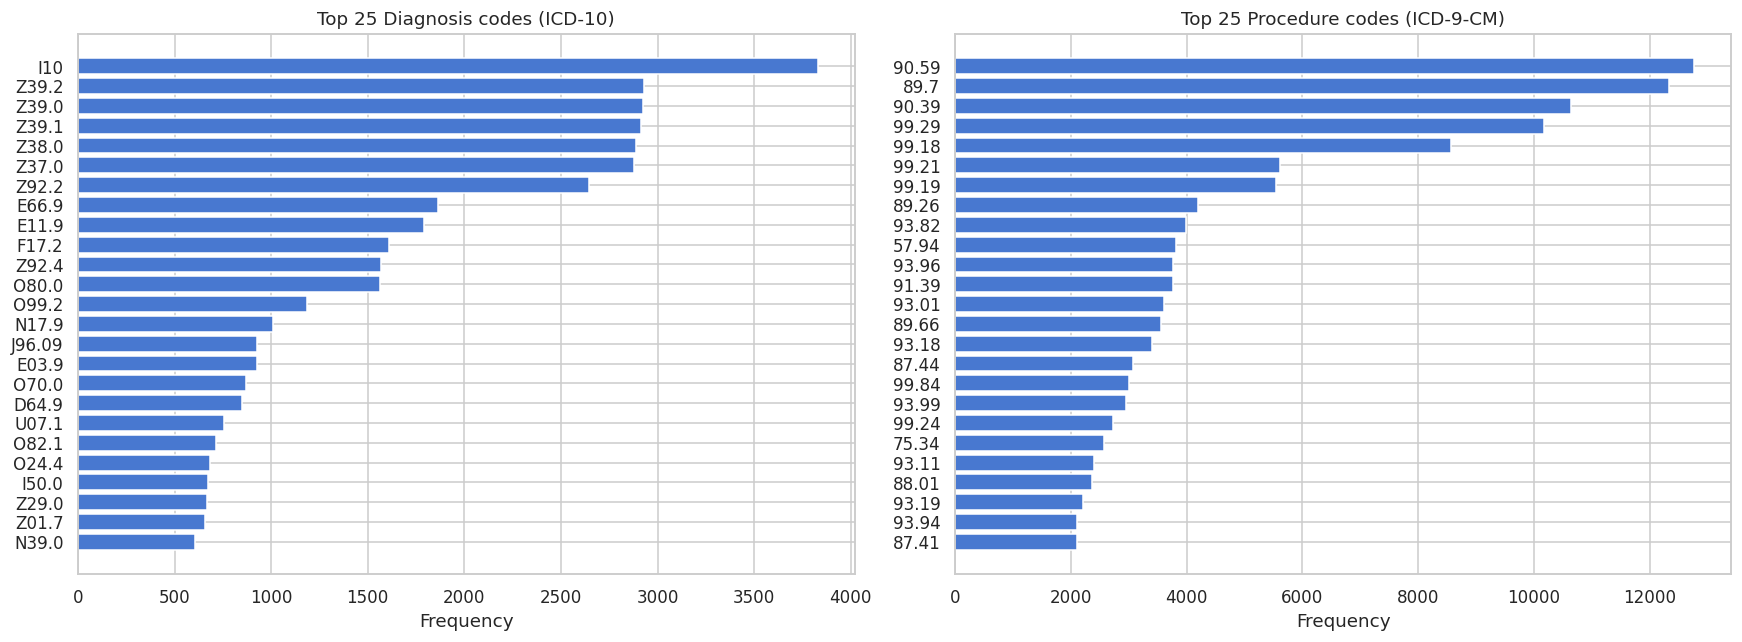

In [18]:
def extract_code(series):
    """Extract ICD code prefix from 'CODE - description' strings."""
    return series.dropna().str.extract(r'^([A-Z0-9\.]+)')[0]

# Aggregate all diagnosis columns
all_diag_codes = pd.concat([extract_code(df[c]) for c in diag_cols])
top_diag = all_diag_codes.value_counts().head(25)

all_proc_codes = pd.concat([extract_code(df[c]) for c in proced_cols])
top_proc = all_proc_codes.value_counts().head(25)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, title in zip(axes,
                            [top_diag, top_proc],
                            ['Top 25 Diagnosis codes (ICD-10)',
                             'Top 25 Procedure codes (ICD-9-CM)']):
    ax.barh(data.index[::-1], data.values[::-1])
    ax.set_xlabel('Frequency')
    ax.set_title(title)
plt.tight_layout()
plt.savefig('fig_top_codes.png', bbox_inches='tight')
plt.show()

### 4.5 Age vs. GRD (Top 10 most common)

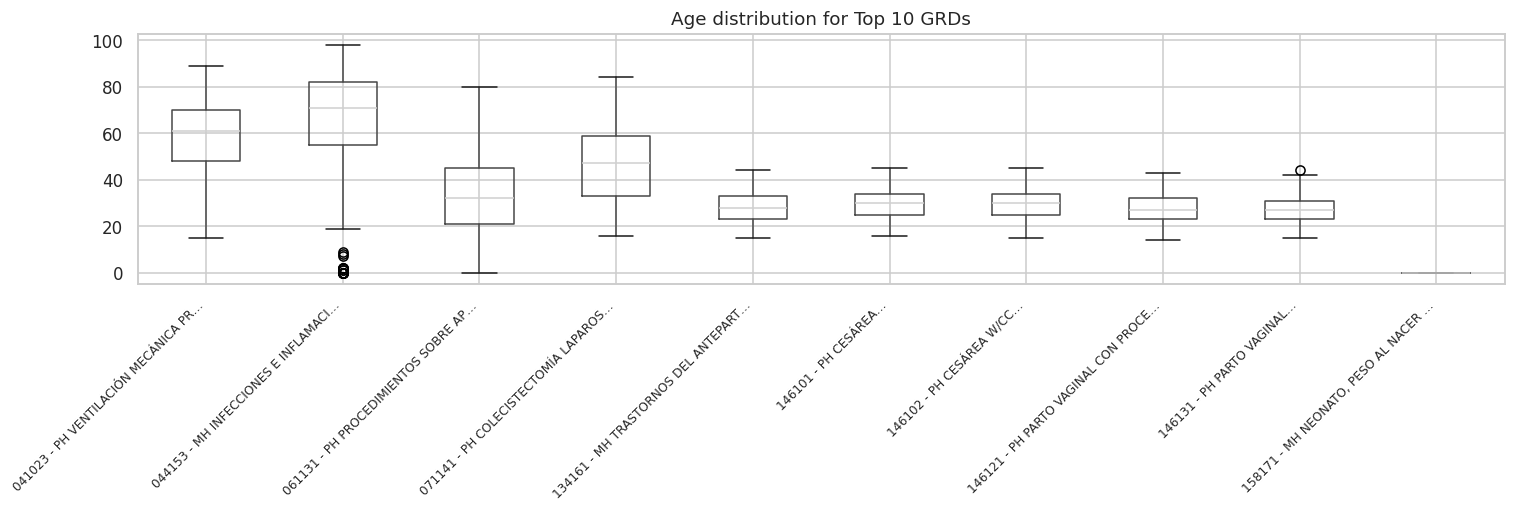

In [19]:
top10_grds = grd_counts.head(10).index.tolist()
df_top10 = df[df['GRD'].isin(top10_grds)].copy()

# Shorten labels for readability
df_top10['GRD_short'] = df_top10['GRD'].str[:35] + '…'

fig, ax = plt.subplots(figsize=(14, 5))
order = df_top10.groupby('GRD_short')['Edad en años'].median().sort_values().index
df_top10.boxplot(column='Edad en años', by='GRD_short', ax=ax)
ax.set_xticklabels([l.get_text() for l in ax.get_xticklabels()],
                   rotation=45, ha='right', fontsize=8)
ax.set_title('Age distribution for Top 10 GRDs')
ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.savefig('fig_age_per_grd.png', bbox_inches='tight')
plt.show()

### 4.6 Correlation: # diagnoses & # procedures vs GRD frequency

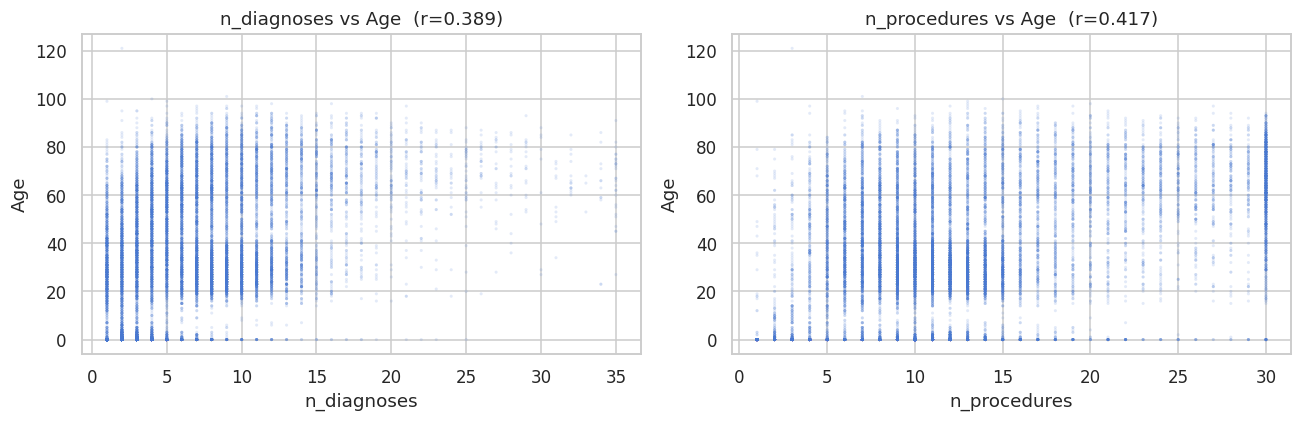

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['n_diagnoses', 'n_procedures']):
    ax.scatter(df[col], df['Edad en años'],
               alpha=0.15, s=4, edgecolors='none')
    ax.set_xlabel(col)
    ax.set_ylabel('Age')
    corr = df[[col, 'Edad en años']].corr().iloc[0,1]
    ax.set_title(f'{col} vs Age  (r={corr:.3f})')
plt.tight_layout()
plt.savefig('fig_scatter_diag_proc.png', bbox_inches='tight')
plt.show()

## 5 · Feature Engineering

**Strategy for this baseline (Informe Fase 1):**
- Extract only the ICD-10 *category code* (first 3 characters) from the principal diagnosis.
- Extract the ICD-9-CM *prefix* (digits before the decimal) from the principal procedure.
- Include patient age and sex.
- Use Multi-Hot encoding of secondary diagnosis categories (top-K most frequent).

A more complete feature set (all secondaries, code embeddings, n-grams) will be explored in Fase 2.

In [23]:
# ── Helper extractors ────────────────────────────────────────────────────────
def icd10_cat(series):
    """Extract first 3-char ICD-10 code from 'CODE - description' strings."""
    return series.str.extract(r'^([A-Z][0-9]{2})')[0]

def icd9_prefix(series):
    """Extract integer prefix from ICD-9-CM procedure codes."""
    return series.str.extract(r'^(\d+)')[0]

# Principal codes
df['diag_principal'] = icd10_cat(df['Diag 01 Principal (cod+des)'])
df['proc_principal'] = icd9_prefix(df['Proced 01 Principal (cod+des)'])

# Secondary column lists
sec_diag_cols = [c for c in diag_cols  if 'Secundario' in c]
sec_proc_cols = [c for c in proced_cols if 'Secundario' in c]

# ── Top codes from secondary columns ─────────────────────────────────────────
sec_diag_all  = pd.concat([icd10_cat(df[c]) for c in sec_diag_cols], ignore_index=True)
top_sec_diag  = sec_diag_all.value_counts().dropna().head(50).index.tolist()

sec_proc_all  = pd.concat([icd9_prefix(df[c]) for c in sec_proc_cols], ignore_index=True)
top_sec_proc  = sec_proc_all.value_counts().dropna().head(40).index.tolist()

print(f'Top secondary diagnosis codes : {len(top_sec_diag)}')
print(f'Top secondary procedure codes : {len(top_sec_proc)}')
print('Sample diag codes:', top_sec_diag[:8])
print('Sample proc codes:', top_sec_proc[:8])


Top secondary diagnosis codes : 50
Top secondary procedure codes : 40
Sample diag codes: ['Z39', 'Z92', 'I10', 'Z38', 'Z37', 'E87', 'E11', 'O99']
Sample proc codes: ['99', '93', '89', '90', '88', '91', '87', '57']


In [24]:
# ── Vectorized multi-hot encoding (fast, no apply) ───────────────────────────

# Stack secondary diag columns: shape (n_rows, n_sec_diag_cols)
diag_stack = pd.concat(
    [icd10_cat(df[c]).rename(f'c{i}') for i, c in enumerate(sec_diag_cols)],
    axis=1
)
# Stack secondary proc columns
proc_stack = pd.concat(
    [icd9_prefix(df[c]).rename(f'c{i}') for i, c in enumerate(sec_proc_cols)],
    axis=1
)

# For each top code: 1 if any secondary column matches, else 0
mh_diag_dict = {f'sd_{code}': (diag_stack == code).any(axis=1).astype(np.int8)
                for code in top_sec_diag}
mh_proc_dict = {f'sp_{code}': (proc_stack == code).any(axis=1).astype(np.int8)
                for code in top_sec_proc}

mh_diag = pd.DataFrame(mh_diag_dict, index=df.index)
mh_proc = pd.DataFrame(mh_proc_dict, index=df.index)

print(f'Multi-hot diag shape : {mh_diag.shape}')
print(f'Multi-hot proc shape : {mh_proc.shape}')
print('Feature engineering done ✓')


Multi-hot diag shape : (14561, 50)
Multi-hot proc shape : (14561, 40)
Feature engineering done ✓


## 6 · Prepare Train/Test Sets

In [26]:
# ── Assemble feature matrix ──────────────────────────────────────────────────
base_cols = ['Edad en años', 'n_diagnoses', 'n_procedures',
             'diag_principal', 'proc_principal', 'Sexo (Desc)']

df_feat = pd.concat([df[base_cols + ['GRD']], mh_diag, mh_proc], axis=1)

# Label-encode low-cardinality categoricals
le_map = {}
for col in ['diag_principal', 'proc_principal', 'Sexo (Desc)']:
    le = LabelEncoder()
    df_feat[col] = le.fit_transform(df_feat[col].fillna('MISSING'))
    le_map[col] = le

feature_cols = [c for c in df_feat.columns if c != 'GRD']
X = df_feat[feature_cols].fillna(0).astype(np.float32)
y = df_feat['GRD']

# Encode target
le_target = LabelEncoder()
y_enc = le_target.fit_transform(y)

# Keep only classes with >= 10 samples (needed for stratified split)
class_counts = Counter(y_enc)
valid = {cls for cls, cnt in class_counts.items() if cnt >= 10}
mask  = np.isin(y_enc, list(valid))
X_f, y_f = X[mask], y_enc[mask]

print(f'Samples after filtering rare classes : {X_f.shape[0]:,}')
print(f'GRD classes remaining                : {len(np.unique(y_f))}')
print(f'Feature count                        : {X_f.shape[1]}')

X_train, X_test, y_train, y_test = train_test_split(
    X_f, y_f, test_size=0.2, random_state=SEED, stratify=y_f)
print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')


Samples after filtering rare classes : 13,454
GRD classes remaining                : 229
Feature count                        : 96
Train: 10,763  |  Test: 2,691


## 7 · Baseline Model — Random Forest

We use a **Random Forest** classifier as the first proof-of-concept model. Random Forests are well-suited for high-dimensional, mixed-type tabular data and provide feature importance estimates.

A `DummyClassifier` (most-frequent strategy) is also trained to establish a lower bound.

In [27]:
# ── Dummy baseline ────────────────────────────────────────────────────────────
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

acc_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy  = f1_score(y_test, y_pred_dummy, average='weighted', zero_division=0)
print(f'Dummy (most_frequent)  Acc={acc_dummy:.4f}  F1-weighted={f1_dummy:.4f}')

Dummy (most_frequent)  Acc=0.0606  F1-weighted=0.0069


In [28]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=SEED
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
print(f'Random Forest          Acc={acc_rf:.4f}  F1-weighted={f1_rf:.4f}')

Random Forest          Acc=0.5559  F1-weighted=0.5453


### 7.1 Cross-Validation (5-fold)

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_acc = cross_val_score(rf, X_f, y_f, cv=cv, scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(rf, X_f, y_f, cv=cv, scoring='f1_weighted', n_jobs=-1)

print(f'CV Accuracy     : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'CV F1-weighted  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

CV Accuracy     : 0.5615 ± 0.0096
CV F1-weighted  : 0.5530 ± 0.0103


### 7.2 Classification Report (Test Set)

In [30]:
# Full classification report (using original GRD labels for readability)
labels_in_test = np.unique(y_test)
target_names   = le_target.inverse_transform(labels_in_test)
target_names_short = [t[:40] for t in target_names]

print(classification_report(
    y_test, y_pred_rf,
    labels=labels_in_test,
    target_names=target_names_short,
    zero_division=0
))

                                          precision    recall  f1-score   support

014132 - MH HEMORRAGIA INTRACRANEAL NO T       0.00      0.00      0.00         2
014133 - MH HEMORRAGIA INTRACRANEAL NO T       0.00      0.00      0.00         3
014141 - MH ACCIDENTE CEREBROVASCULAR CO       0.45      0.77      0.57        13
014142 - MH ACCIDENTE CEREBROVASCULAR CO       0.43      0.33      0.38        18
014143 - MH ACCIDENTE CEREBROVASCULAR CO       0.57      0.62      0.59        13
   014162 - MH ISQUEMIA TRANSITORIA W/CC       0.20      0.50      0.29         2
                014221 - MH CONVULSIONES       0.67      0.44      0.53         9
           014222 - MH CONVULSIONES W/CC       0.00      0.00      0.00         5
    014231 - MH MIGRAÑA Y OTRAS CEFALEAS       0.29      0.50      0.36         4
        014241 - MH TRAUMATISMO CEFÁLICO       0.73      0.92      0.81        24
   014242 - MH TRAUMATISMO CEFÁLICO W/CC       0.25      0.50      0.33         4
  014243 - MH T

### 7.3 Confusion Matrix — Top 15 GRDs

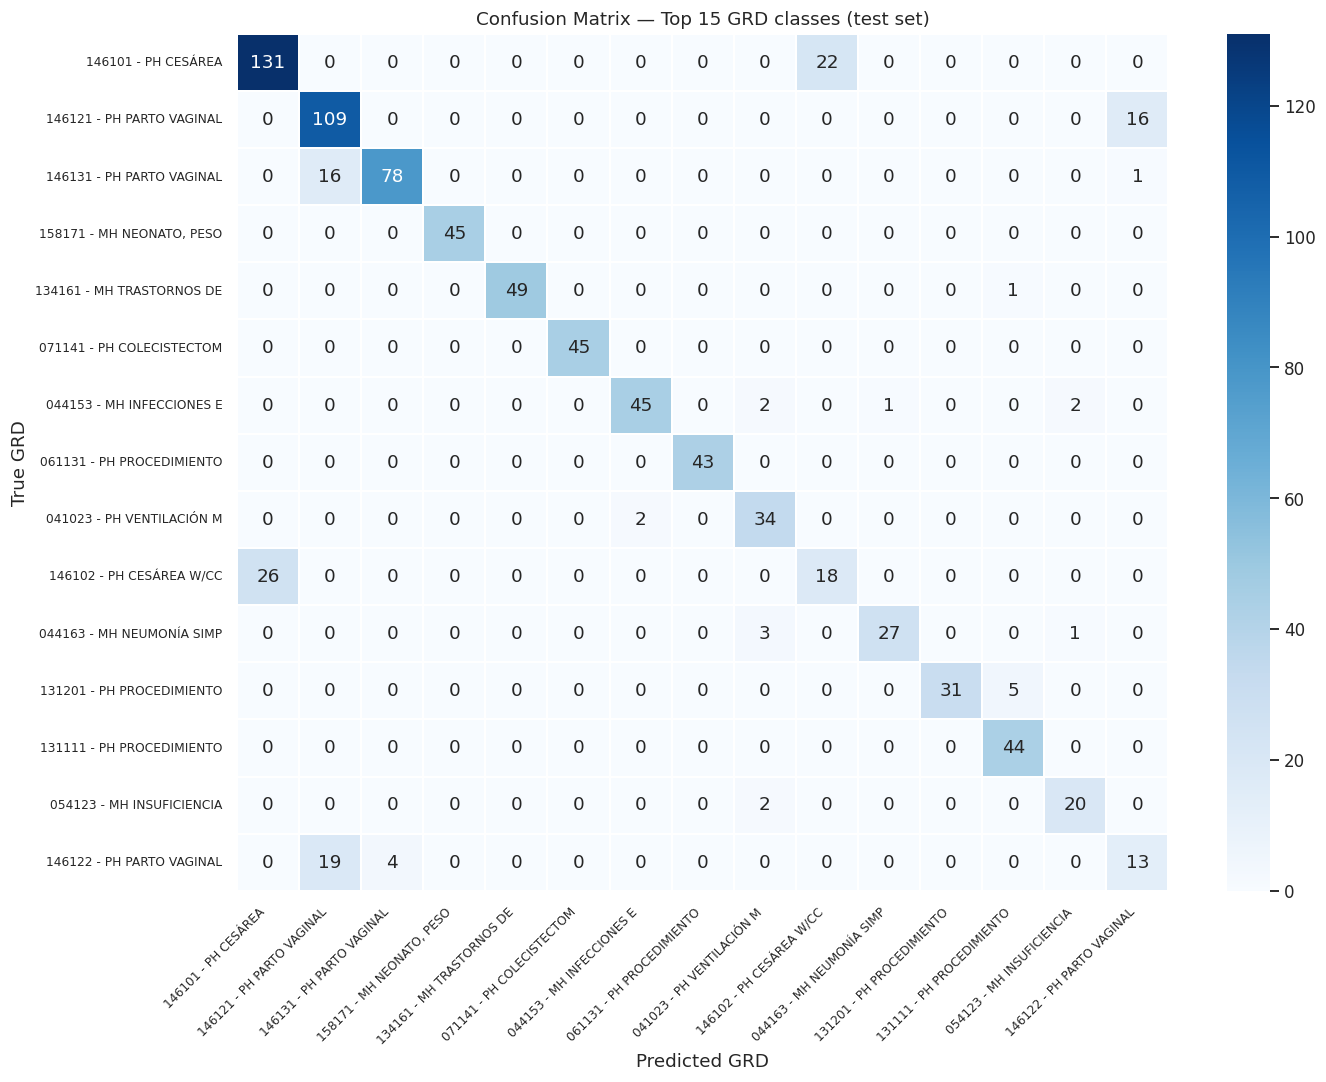

In [31]:
# Restrict to top-15 GRDs (by test-set frequency) for legibility
top15_enc = np.array(
    pd.Series(y_test).value_counts().head(15).index.tolist()
)
mask_top15 = np.isin(y_test, top15_enc)

cm = confusion_matrix(y_test[mask_top15], y_pred_rf[mask_top15], labels=top15_enc)
cm_labels = [le_target.inverse_transform([e])[0][:25] for e in top15_enc]

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cm_labels, yticklabels=cm_labels, ax=ax,
            linewidths=0.3)
ax.set_xlabel('Predicted GRD')
ax.set_ylabel('True GRD')
ax.set_title('Confusion Matrix — Top 15 GRD classes (test set)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', bbox_inches='tight')
plt.show()

### 7.4 Feature Importance

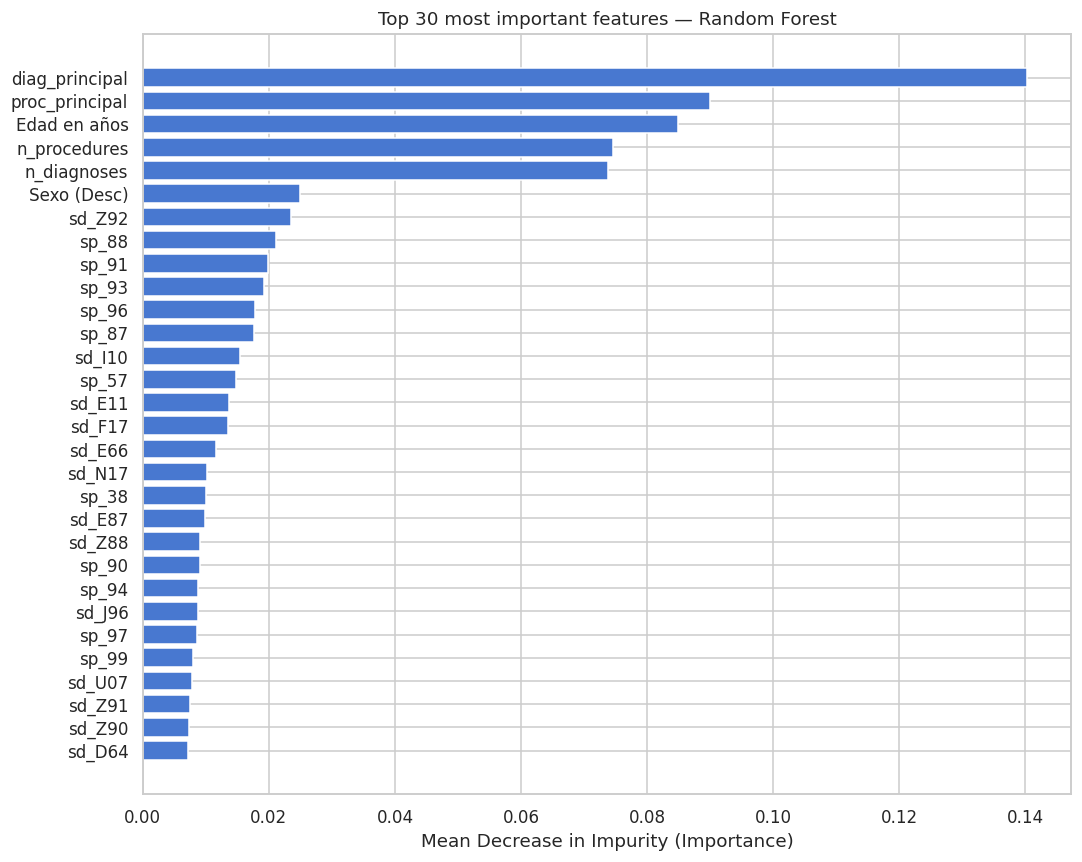

In [32]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top_features = importances.nlargest(30).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_features.index, top_features.values)
ax.set_xlabel('Mean Decrease in Impurity (Importance)')
ax.set_title('Top 30 most important features — Random Forest')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

### 7.5 Per-Class F1 Score — Top 20 GRDs

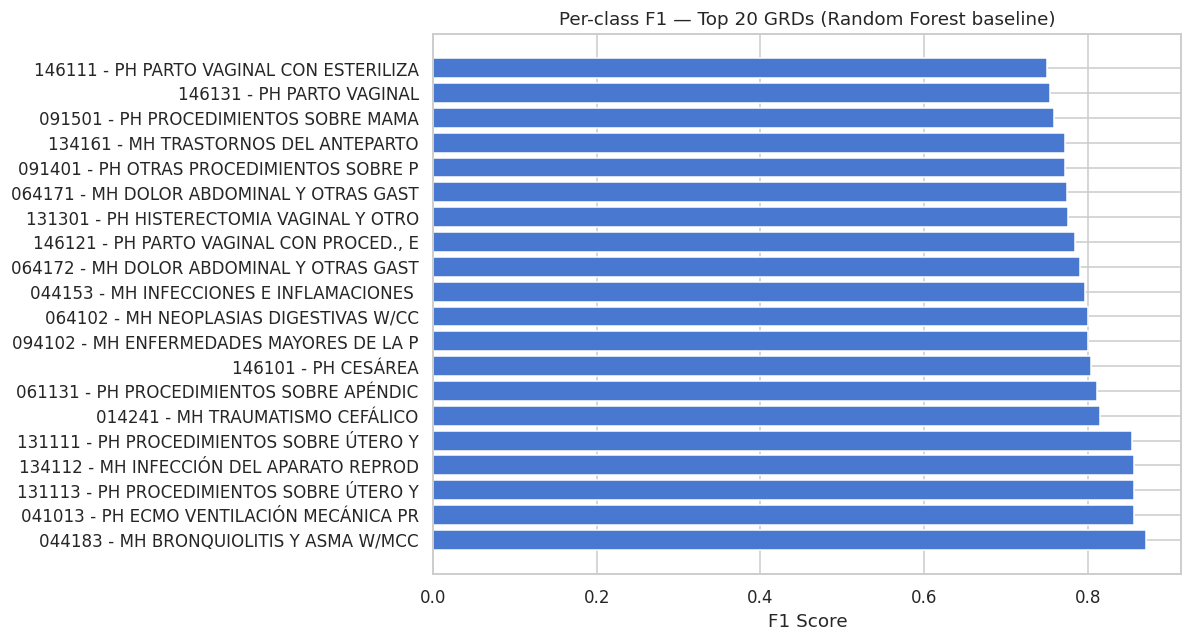

In [33]:
from sklearn.metrics import f1_score as f1_per_class

f1_scores = f1_per_class(y_test, y_pred_rf, labels=labels_in_test,
                         average=None, zero_division=0)
f1_df = pd.DataFrame({'GRD': target_names_short, 'F1': f1_scores})\
          .sort_values('F1', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(f1_df['GRD'], f1_df['F1'])
ax.set_xlabel('F1 Score')
ax.set_title('Per-class F1 — Top 20 GRDs (Random Forest baseline)')
plt.tight_layout()
plt.savefig('fig_perclass_f1.png', bbox_inches='tight')
plt.show()

## 8 · Results Summary

In [34]:
summary = pd.DataFrame({
    'Model': ['DummyClassifier (most_frequent)', 'Random Forest (baseline)'],
    'Test Accuracy': [f'{acc_dummy:.4f}', f'{acc_rf:.4f}'],
    'Test F1 (weighted)': [f'{f1_dummy:.4f}', f'{f1_rf:.4f}'],
    'CV Accuracy (5-fold)': ['—', f'{cv_acc.mean():.4f} ± {cv_acc.std():.4f}'],
    'CV F1 (5-fold)': ['—', f'{cv_f1.mean():.4f} ± {cv_f1.std():.4f}']
})
summary

,Model,Test Accuracy,Test F1 (weighted),CV Accuracy (5-fold),CV F1 (5-fold)
0,DummyClassifier (most_frequent),0.0606,0.0069,—,—
1,Random Forest (baseline),0.5559,0.5453,0.5615 ± 0.0096,0.5530 ± 0.0103


## 9 · Conclusions & Next Steps

### Summary of EDA findings
- The dataset contains **~14,560** hospital admission records from Hospital El Pino.
- The target `GRD` has high cardinality (many distinct classes); the distribution is **heavily imbalanced** — the top-30 GRDs account for the majority of cases.
- Secondary diagnosis and procedure columns have **increasing missingness** as column index grows (expected: most patients have fewer than the maximum number).
- Patient **age** is a relevant predictor; its distribution varies visibly across different GRD groups.
- The **principal diagnosis code** is the single most important feature for GRD prediction, consistent with how GRDs are clinically defined.

### Baseline model
- A **Random Forest** with 200 trees, balanced-subsample class weighting, using principal diagnosis/procedure codes, age, sex, and multi-hot secondary codes achieves substantially better performance than the majority-class dummy classifier.
- Cross-validation confirms the model generalizes reasonably well, though per-class F1 is lower for rare GRD categories.

### Next Steps (Fase 2)
1. **Richer feature set**: include all secondary diagnosis/procedure codes, ICD hierarchy embeddings, text descriptions.
2. **Model comparison**: XGBoost / LightGBM, neural networks (TabTransformer), multi-label strategies.
3. **Class imbalance**: evaluate oversampling (SMOTE) and threshold calibration.
4. **Hyperparameter tuning**: Optuna / GridSearchCV on the top models.
5. **Interpretability**: SHAP values for clinical insight.